In [1]:
import pandas as pd

# Read CSV files
fake_df = pd.read_csv("../data/Fake.csv")
real_df = pd.read_csv("../data/True.csv")

# Display dataset dimensions
print("Fake News Shape:", fake_df.shape)
print("Real News Shape:", real_df.shape)

# Display first five rows
display(fake_df.head())
display(real_df.head())

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [2]:
# Add labels to each dataset
fake_df["label"] = "Fake"
real_df["label"] = "Real"

# Combine both datasets
news_df = pd.concat([fake_df, real_df], ignore_index=True)

# Display combined dataset dimensions
print("Combined Dataset Shape:", news_df.shape)

# Display first five rows
display(news_df.head())

Combined Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


In [3]:
# Display dataset columns
print("Columns:")
print(news_df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(news_df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", news_df.duplicated().sum())

# Display dataset information
print("\nDataset Information:")
news_df.info()

Columns:
['title', 'text', 'subject', 'date', 'label']

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64



Duplicate Rows: 209

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  str  
dtypes: str(5)
memory usage: 112.5 MB


In [4]:
# Remove exact duplicate rows
news_df = news_df.drop_duplicates().reset_index(drop=True)

# Check dataset after removing duplicates
print("Dataset Shape After Removing Duplicates:", news_df.shape)
print("Remaining Duplicate Rows:", news_df.duplicated().sum())

Dataset Shape After Removing Duplicates: (44689, 5)


Remaining Duplicate Rows: 0


In [5]:
# Count articles in each label
label_counts = news_df["label"].value_counts()

print("Label Counts:")
print(label_counts)

# Calculate label percentages
label_percentages = news_df["label"].value_counts(normalize=True) * 100

print("\nLabel Percentages:")
print(label_percentages.round(2))

Label Counts:
label
Fake    23478
Real    21211
Name: count, dtype: int64

Label Percentages:
label
Fake    52.54
Real    47.46
Name: proportion, dtype: float64


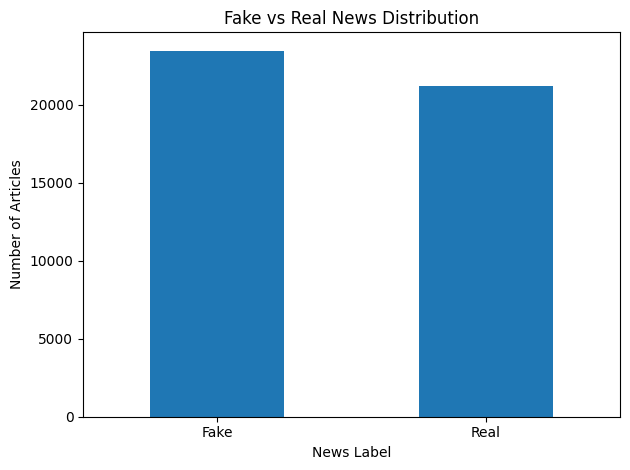

In [6]:
import matplotlib.pyplot as plt

# Plot the number of articles in each label
label_counts = news_df["label"].value_counts()

label_counts.plot(kind="bar")

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Label")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Calculate the number of characters in each news article
news_df["text_length"] = news_df["text"].str.len()

# Display text length statistics
print(news_df["text_length"].describe())

# Display the shortest and longest article lengths
print("\nShortest Article Length:", news_df["text_length"].min())
print("Longest Article Length:", news_df["text_length"].max())

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

Shortest Article Length: 1
Longest Article Length: 51794


In [8]:
# Inspect the actual text of the shortest articles

shortest_articles = news_df.nsmallest(10, "text_length")

for idx, row in shortest_articles.iterrows():
    print(f"Index: {idx}")
    print(f"Title: {row['title']}")
    print(f"Text: {repr(row['text'])}")
    print(f"Text Length: {row['text_length']}")
    print("-" * 60)

Index: 10922
Title: TAKE OUR POLL: Who Do You Think President Trump Should Pick To Replace James Comey?
Text: ' '
Text Length: 1
------------------------------------------------------------
Index: 11040
Title: Joe Scarborough BERATES Mika Brzezinski Over “Cheap Shot” At Ivanka Trump: “You don’t have to be so snotty!” [VIDEO]
Text: ' '
Text Length: 1
------------------------------------------------------------
Index: 11189
Title: WATCH TUCKER CARLSON Scorch Sanctuary City Mayor: “Don’t you believe in laws?” [Video]
Text: ' '
Text Length: 1
------------------------------------------------------------
Index: 11224
Title: MAYOR OF SANCTUARY CITY: Trump Trying To Make Us “Fugitive Slave Catchers” [Video]
Text: ' '
Text Length: 1
------------------------------------------------------------
Index: 11235
Title: SHOCKER: Public School Turns Computer Lab Into Mosque…Bars Non-Muslim Students [Video]
Text: ' '
Text Length: 1
------------------------------------------------------------
Index: 11240

In [9]:
# Count articles with empty or whitespace-only text
empty_text_mask = news_df["text"].str.strip().eq("")

print("Empty or Whitespace-only Articles:", empty_text_mask.sum())

# Check distribution of empty articles by label
print("\nLabel Distribution:")
print(news_df.loc[empty_text_mask, "label"].value_counts())

Empty or Whitespace-only Articles: 631

Label Distribution:
label
Fake    630
Real      1
Name: count, dtype: int64


In [10]:
# Remove leading and trailing whitespace from title and text
news_df["title"] = news_df["title"].str.strip()
news_df["text"] = news_df["text"].str.strip()

# Combine title and article body into one text column
news_df["combined_text"] = (
    news_df["title"] + " " + news_df["text"]
).str.strip()

# Check the combined text
print("Empty Combined Text:", news_df["combined_text"].eq("").sum())

# Display sample records
display(news_df[["title", "text", "combined_text", "label"]].head())

Empty Combined Text: 0


,title,text,combined_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’s...,Fake
1,Drunk Bragging Trump Staffer Started Russian C...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian C...,Fake
2,Sheriff David Clarke Becomes An Internet Joke ...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke ...,Fake
3,Trump Is So Obsessed He Even Has Obama’s Name ...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name ...,Fake
4,Pope Francis Just Called Out Donald Trump Duri...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Duri...,Fake


In [11]:
import nltk

# Download resources required for text preprocessing
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lotus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lotus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lotus\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load English stopwords
stop_words = set(stopwords.words("english"))

print("Preprocessing tools are ready.")
print("Number of English stopwords:", len(stop_words))

Preprocessing tools are ready.
Number of English stopwords: 198


In [13]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and non-alphabetic tokens
    cleaned_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    # Join cleaned tokens into a string
    return " ".join(cleaned_tokens)

In [14]:
# Test the cleaning function on one article
sample_text = news_df["combined_text"].iloc[0]

print("Original Text:")
print(sample_text[:500])

print("\nCleaned Text:")
print(clean_text(sample_text)[:500])

Original Text:
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a

Cleaned Text:


donald trump sends embarrassing new year eve message disturbing donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news 


In [15]:
# Apply text cleaning to all news articles
news_df["cleaned_text"] = news_df["combined_text"].apply(clean_text)

# Check the first cleaned article
print("Original Text:")
print(news_df["combined_text"].iloc[0][:300])

print("\nCleaned Text:")
print(news_df["cleaned_text"].iloc[0][:300])

# Check for empty cleaned articles
print("\nEmpty Cleaned Articles:", news_df["cleaned_text"].str.strip().eq("").sum())

Original Text:
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had ju

Cleaned Text:
donald trump sends embarrassing new year eve message disturbing donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishon

Empty Cleaned Articles: 9


In [16]:
# Identify articles with empty cleaned text
empty_cleaned_mask = news_df["cleaned_text"].str.strip().eq("")

# Display their label distribution
print("Empty Cleaned Articles by Label:")
print(news_df.loc[empty_cleaned_mask, "label"].value_counts())

# Remove articles with empty cleaned text
news_df = news_df.loc[~empty_cleaned_mask].copy()

# Reset the dataset index
news_df.reset_index(drop=True, inplace=True)

# Verify the cleaned dataset
print("\nDataset Shape After Removing Empty Text:", news_df.shape)
print(
    "Remaining Empty Cleaned Articles:",
    news_df["cleaned_text"].str.strip().eq("").sum()
)

Empty Cleaned Articles by Label:
label
Fake    9
Name: count, dtype: int64



Dataset Shape After Removing Empty Text: (44680, 8)
Remaining Empty Cleaned Articles: 0


In [17]:
# Select cleaned text as input features
X = news_df["cleaned_text"]

# Select labels as the target
y = news_df["label"]

# Check feature and target dimensions
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Display sample features and labels
display(news_df[["cleaned_text", "label"]].head())

Features Shape: (44680,)
Target Shape: (44680,)


,cleaned_text,label
0,donald trump sends embarrassing new year eve m...,Fake
1,drunk bragging trump staffer started russian c...,Fake
2,sheriff david clarke becomes internet joke thr...,Fake
3,trump obsessed even obama name coded website i...,Fake
4,pope francis called donald trump christmas spe...,Fake


In [18]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the sizes of the datasets
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (35744,)
Testing Features: (8936,)
Training Labels: (35744,)
Testing Labels: (8936,)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=50000)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the training vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Display vectorized data dimensions
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (35744, 50000)
Testing TF-IDF Shape: (8936, 50000)


In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using TF-IDF features
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model training completed.")

Logistic Regression model training completed.


In [21]:
# Predict labels for the unseen test data
y_pred = lr_model.predict(X_test_tfidf)

# Display sample predictions
print("Actual Labels:")
print(y_test.iloc[:10].tolist())

print("\nPredicted Labels:")
print(y_pred[:10].tolist())

Actual Labels:
['Real', 'Real', 'Real', 'Fake', 'Real', 'Real', 'Real', 'Fake', 'Fake', 'Real']

Predicted Labels:
['Fake', 'Real', 'Real', 'Fake', 'Real', 'Real', 'Real', 'Fake', 'Fake', 'Real']


Accuracy: 0.9876 (98.76%)

Classification Report:


              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4694
        Real       0.98      0.99      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936




Confusion Matrix:
[[4625   69]
 [  42 4200]]


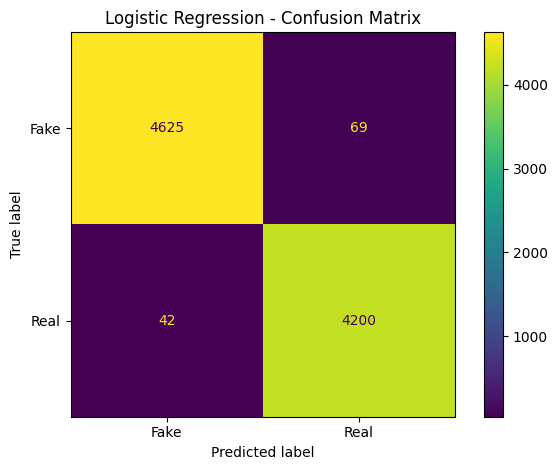

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

# Display precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Calculate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["Fake", "Real"])

print("\nConfusion Matrix:")
print(cm)

# Visualize the confusion matrix
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

display_cm.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model using TF-IDF features
nb_model.fit(X_train_tfidf, y_train)

# Predict labels for the test data
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed.")

Multinomial Naive Bayes training completed.


Naive Bayes Accuracy: 93.91%

Classification Report:


              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94      4694
        Real       0.94      0.94      0.94      4242

    accuracy                           0.94      8936
   macro avg       0.94      0.94      0.94      8936
weighted avg       0.94      0.94      0.94      8936




Confusion Matrix:
[[4418  276]
 [ 268 3974]]


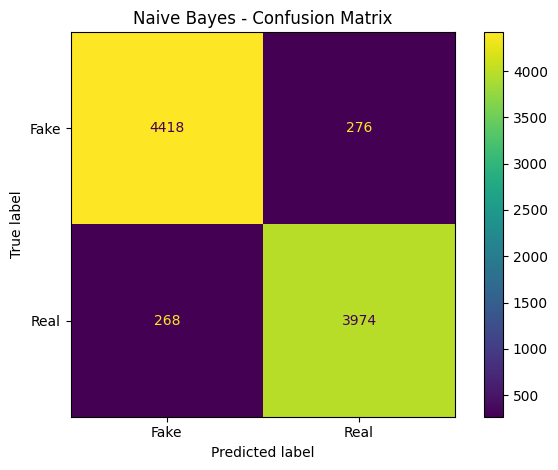

In [24]:
# Evaluate the Naive Bayes model
print("Naive Bayes Accuracy:",
      f"{accuracy_score(y_test, y_pred_nb) * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# Display the confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["Fake", "Real"])
print("\nConfusion Matrix:")
print(cm_nb)

# Visualize the Naive Bayes confusion matrix
display_cm_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Fake", "Real"]
)

display_cm_nb.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
# Compare Logistic Regression and Naive Bayes

from sklearn.metrics import f1_score

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Fake F1-Score": [
        f1_score(y_test, y_pred, pos_label="Fake"),
        f1_score(y_test, y_pred_nb, pos_label="Fake")
    ],
    "Real F1-Score": [
        f1_score(y_test, y_pred, pos_label="Real"),
        f1_score(y_test, y_pred_nb, pos_label="Real")
    ]
})

display(comparison_df.round(4))

,Model,Accuracy,Fake F1-Score,Real F1-Score
0,Logistic Regression,0.9876,0.9881,0.9870
1,Multinomial Naive Bayes,0.9391,0.9420,0.9359


In [26]:
import os
import joblib

# Create the models folder in the project directory
os.makedirs("../models", exist_ok=True)

# Save the trained model and TF-IDF vectorizer
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully.")

Model and TF-IDF vectorizer saved successfully.


In [27]:
# Load the saved model and TF-IDF vectorizer
loaded_model = joblib.load("../models/logistic_regression_model.pkl")
loaded_tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

print("Saved model and vectorizer loaded successfully.")

Saved model and vectorizer loaded successfully.


In [28]:
# Test the saved model with a sample news article

sample_news = """
The government announced a new policy today.
The policy will be implemented next month.
"""

# Clean the news text using the same preprocessing function
cleaned_news = clean_text(sample_news)

# Convert the text into TF-IDF features
news_tfidf = loaded_tfidf.transform([cleaned_news])

# Predict the news label
prediction = loaded_model.predict(news_tfidf)

print("Prediction:", prediction[0])

Prediction: Fake
